# Phase 2 - Unsupervised Learning
## IBM HR Employee Attrition Dataset
---

## **Clustering Rationale & Algorithm Selection**

### 1. K-means

#### i. Dataset Characteristics
#### ii. Expected Cluster Shapes
#### iii. Scalability
#### iv. Interpretability
#### iv. Model Strengths for This Problem
**Strengths:**
**Weaknesses:**

### 2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
DBSCAN is a density-based clustering algorithm that groups employees based on how close they are to each other, it discovers clusters automatically by analyzing the density different areas of the data are.


#### i. Dataset Characteristics
- Our dataset size is a small to medium dataset (1,470 employees).
- After preprocessing the dataset in phase 1, we are going to deal with 50 features which are all of numeric type, scaled, and clean with no missing values.

#### ii. Expected Cluster Shapes
- DBSCAN finds arbitrary-shaped clusters and not just spheres like K-Means.

#### iii. Scalability
- Looking at the data size, DBSCAN performs O(n²) which is ~2.1 million distance comparisons that would execute in seconds
- No performance concerns for this data size

#### iv. Interpretability
- Clusters can be profiled by analyzing mean characteristics (age, salary, attrition rate), and each employee gets a clear cluster label or outlier designation.
- Results are directly meaningful for HR decisions (e.g., "high-risk junior staff")
- DBSCAN identifies outliers which provides an insights instead of forcing unusual employees into inappropriate clusters


#### iv. Model Strengths for This Problem
**Strengths:**
- No need to specify number of clusters
- Handles arbitrary cluster shapes
- Identifies outliers automatically
- Reproducible (no random initialization)

**Weaknesses:**
- Sensitive to eps parameter
- Struggles with varying density clusters
- Requires careful tuning

### 3. Agglomerative Hierarchical Clustering

#### i. Dataset Characteristics
#### ii. Expected Cluster Shapes
#### iii. Scalability
#### iv. Interpretability
#### iv. Model Strengths for This Problem
**Strengths:**
**Weaknesses:**

---

## **Data Preparation**


**NOTE:** Most of the data preprocessing (missing value handling and some feature scaling) was completed in Phase 1.
However, in our current phase where we are dealing with unsupervised learning, there are some adjustments that need to be made on the used preprocessed data to avoid problems in clustering.

This section only performs the necessary transformation for unsupervised learning which are:
1. Encoding two binary columns which are still stored as text in preprocessed_data.csv, Gender(Femal/Male) and OverTime(Yes/No) to 0/1.
2. Removeing the class label "Attrition".
3. Removing redundant derived columns (SatisfactionScore, LowSatisfactionFlag, AgeGroup) where
    - "SatisfactionScore" is the direct average of (JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction)
    - "LowSatisfactionFlag" is a 0/1 cut of the satisfaction avrage score. 
    - "AgeGroup" is just the same as "Age" but slpit into buckets.

These columns were intentionally engineered in Phase 1 to give supervised models additional ways to detect attrition patterns, and redundancy is harmless there because the label guides what the model pays attention to. In clustering there is no label and distance across all columns is the only tool, so having satisfaction counted five times artificially pulls that dimension to dominate every cluster assignment.

4. Re-scaling all features using StandardScaler. Even though most continuous features were scaled in Phase 1, several ordinal columns (Education, JobLevel, WorkLifeBalance, etc.) and the three engineered ratio features (IncomePerYear, PromotionRatio, RoleStabilityRatio) were left on their original scales. This was not a problem for supervised learning since tree-based models are scale-invariant and Logistic Regression was robust enough to handle it. For clustering it must be fixed since distance is measured equally across all columns, so any column with a larger numeric range will dominate cluster assignments regardless of how important it actually is.


**Important limitation (Attrition imbalance):** The IBM HR dataset is strongly imbalanced — **84% of employees did not leave** and only **16% did**. In this phase we do not use Attrition to form clusters, but we do use it later to profile clusters (attrition rate per cluster). Because the "Yes" cases are relatively rare, small clusters can show 0% or very high attrition simply due to small sample size, so conclusions about high-risk clusters should be treated as **indicative**, not definitive.


In [17]:
# ── IMPORTS ───────────────────────────────────────────────────────

#for loading and manipulating our dataset
import pandas as pd

#for numerical operations
import numpy as np

#for creating plots and visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#to turn off minor warnings so the output stays clean and readable
import warnings
warnings.filterwarnings('ignore')

# ── Here are the libraries we will use which are needed for clustering, aside from data preparation ───────────────────────────────────────────────────────

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from sklearn.preprocessing import StandardScaler


# Set visualization style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully.")

All libraries imported successfully.


In [18]:
# Load the preprocessed data from Phase 1
df_full = pd.read_csv('Dataset/preprocessed_data.csv')

print("Dataset loaded from Phase 1 preprocessing")
print(f"\nDataset Information:")
print(f"  Shape: {df_full.shape[0]} rows × {df_full.shape[1]} columns")
print(f"  Features: {df_full.shape[1] - 1} (after target variable)")
print(f"  Observations: {df_full.shape[0]} employees")
print(f"  Target variable 'Attrition': {'Yes' if 'Attrition' in df_full.columns else 'No'}")

Dataset loaded from Phase 1 preprocessing

Dataset Information:
  Shape: 1470 rows × 54 columns
  Features: 53 (after target variable)
  Observations: 1470 employees
  Target variable 'Attrition': Yes


In [ ]:
# ── Step 1: Encode binary text columns to 0/1 ────────────────────

# There are two binary columns which are still stored as text in preprocessed_data.csv that needs to be encoded
df_full['Gender'] = df_full['Gender'].map({'Female': 0, 'Male': 1})
df_full['OverTime'] = df_full['OverTime'].map({'No': 0, 'Yes': 1})

print("Gender encoded:  ", df_full['Gender'].unique())
print("OverTime encoded:", df_full['OverTime'].unique())

Gender encoded:   [0 1]
OverTime encoded: [1 0]


In [20]:
# ── Step 2: Save Attrition separately, then remove it with step 3 ────────────

# We will keep a copy of Attrition for later analysis and evaluation of clusters, but we won't use it for clustering itself
attrition_labels = df_full['Attrition'].copy()

# ── Step 3: Drop redundant derived columns ───────────────────────

# 'SatisfactionScore', 'LowSatisfactionFlag', 'AgeGroup' are the redundant columns as explained above so they will be removed along with the target label 'Attrition'.
cols_to_drop = ['Attrition', 'SatisfactionScore', 'LowSatisfactionFlag', 'AgeGroup']
X = df_full.drop(columns=cols_to_drop).copy()

print(f"Columns dropped: {cols_to_drop}")
print(f"Features remaining: {X.shape[1]}")

# A quick check before scaling to confirm no string columns remain.
# If any appear here the scaler will raise an error.
remaining_strings = X.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Non-numeric columns remaining: {remaining_strings}")  # should be []

Columns dropped: ['Attrition', 'SatisfactionScore', 'LowSatisfactionFlag', 'AgeGroup']
Features remaining: 50
Non-numeric columns remaining: []


In [21]:
# ── Step 4: Scale all features to the same range ─────────────────

# Phase 1 CSV mixes z-scored features, raw Likert scales, and large engineered column
# we will rescale so no single feature dominates distance when its used in algorithms that uses distance metrics such as DBSCAN.
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X.astype(float)),
    columns=X.columns,
    index=X.index
)

print(f"Scaling complete.")
print(f"  Samples : {X_scaled.shape[0]}")
print(f"  Features: {X_scaled.shape[1]}")
print(f"\nSample means after scaling (should all be ~0):")
print(X_scaled.mean().round(6).head(5))
print(f"\nSample stds after scaling (should all be ~1):")
print(X_scaled.std().round(6).head(5))
print(f"\nX_scaled is ready for clustering.")

Scaling complete.
  Samples : 1470
  Features: 50

Sample means after scaling (should all be ~0):
Age                -0.0
BusinessTravel     -0.0
DailyRate           0.0
DistanceFromHome    0.0
Education           0.0
dtype: float64

Sample stds after scaling (should all be ~1):
Age                 1.00034
BusinessTravel      1.00034
DailyRate           1.00034
DistanceFromHome    1.00034
Education           1.00034
dtype: float64

X_scaled is ready for clustering.


---

## Cluster Determination & Implementation

### 1. K-means

### 2. DBSCAN

To apply this algorithm there are two parameters which are required to be set:

1. **eps**, which is the maximum distance between points to be considered neighbors
   - Too small = many small clusters and noise
   - Too large = all points merge into one cluster
   - We need to find the "right" value

2. **min_samples**, which is the minimum neighbors needed to form a cluster, and are going to set it to 5 as its the defult number to use for DBSCAN

So in order to find the optimal eps we will go through three steps:
**Step 1: K-Distance Graph**
**Step 2: Test Multiple eps Values**
**Step 3: Select Best eps**

and only then we are going to run DBSCAN with the best found eps.


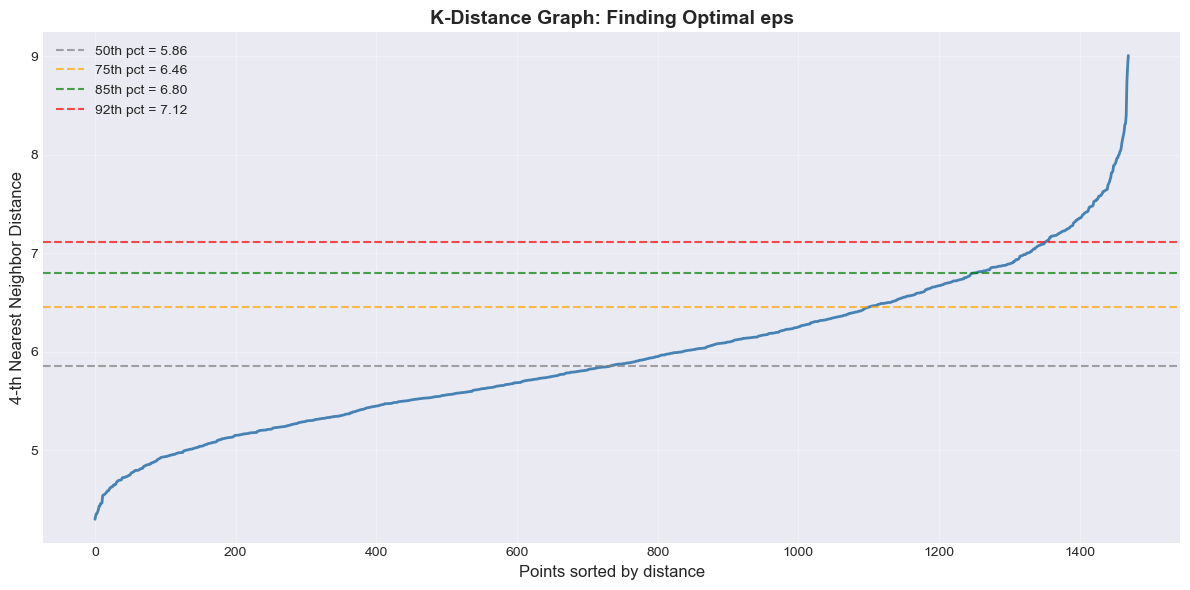

K-Distance statistics:
  Min: 4.2955
  Mean: 5.9523
  Median: 5.8573
  Max: 9.0098

Look for the 'elbow' where distance suddenly increases


In [22]:
# ── K-Distance Graph ───────────────────────────────────────────────────────

# Firstly we are calculating k-distances by ploting distance from each employee to their k-th nearest neighbor
# We are looking for the "elbow" (sudden jump), this suggests good eps values
k = 4  # We use min_samples=5, so k=4 (k = min_samples - 1)

# Find k nearest neighbors for each point (use scaled matrix — same space as DBSCAN)
neighbors = NearestNeighbors(n_neighbors=k+1)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort the distances to the k-th nearest neighbor (classic k-distance plot)
distances = np.sort(distances[:, k], axis=0)

# Create the k-distance graph (shows us where to pick eps)
plt.figure(figsize=(12, 6))
plt.plot(distances, linewidth=2, color='steelblue')
plt.xlabel('Points sorted by distance', fontsize=12)
plt.ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=12)
plt.title('K-Distance Graph: Finding Optimal eps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Reference lines: eps must be on THIS vertical scale (old 0.5–2.0 lines were far below the elbow → all noise)
for pct, color in [(50, 'gray'), (75, 'orange'), (85, 'green'), (92, 'red')]:
    yref = np.percentile(distances, pct)
    plt.axhline(y=yref, color=color, linestyle='--', alpha=0.7, label=f'{pct}th pct = {yref:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# Print statistics to help choose eps
print(f"K-Distance statistics:")
print(f"  Min: {distances.min():.4f}")
print(f"  Mean: {distances.mean():.4f}")
print(f"  Median: {np.median(distances):.4f}")
print(f"  Max: {distances.max():.4f}")
print(f"\nLook for the 'elbow' where distance suddenly increases")

In [23]:
# ── Test Multiple eps Values ───────────────────────────────────────────────────────

# Here we are going to test multiple eps values
# And to choose which is the optimal eps, we will evaluate the number of clusters, noise points, and quality metrics (Silhouette Score and Davies-Bouldin Index) for each value of eps

# The k-distance graph from the previous cell showed no sharp single elbow where the curve rises gradually
# from ~4.3 to ~6.8 then shoots up steeply after point 1,300, placing the elbow in the 85th–92nd percentile zone (6.80–7.12).
#
# A broad initial sweep across [5.0 – 9.0] revealed that:
#   - eps < 6.0  → too many clusters with 50–80% of employees labeled as noise
#   - eps > 7.0  → one cluster absorbs 93%+ of employees (uninterpretable)
#   - eps 6.0–7.0 → the meaningful zone: 4–8 clusters, noise under 25%
#
# This refined grid focuses within that meaningful zone to find the optimal eps using a combined Silhouette + Davies-Bouldin score.
eps_candidates = [6.0, 6.2, 6.4, 6.5, 6.6, 6.7, 6.8, 7.0]
min_samples = 5  # Minimum points needed to form a cluster, and it is chosen as the defult value in using DBSCAN algorithm.
results = []

print(f"Testing DBSCAN with different eps values (min_samples={min_samples})...\n")
print(f"{'eps':>6} | {'Clusters':>8} | {'Noise':>6} | {'Silhouette':>11} | {'Davies-Bouldin':>15} | {'Largest':>7}")
print("-" * 82)

# Try each eps value
for eps in eps_candidates:
    # Apply DBSCAN with this eps value
    db = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = db.fit_predict(X_scaled)
    
    # Count how many clusters and noise points were found
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = list(clusters).count(-1)
    n_points = len(clusters) - n_noise

    # Detect "one mega-cluster + tiny sliver" (common when eps is too large) — bad for interpretation
    if n_clusters > 0:
        non_noise_sizes = [(clusters == cid).sum() for cid in set(clusters) if cid != -1]
        largest_cluster_share = max(non_noise_sizes) / len(clusters)
    else:
        largest_cluster_share = 1.0
    
    # Calculate quality metrics only if we have at least 2 clusters
    if n_clusters > 1 and n_points > 0:
        mask = clusters != -1  # Exclude noise points
        sil_score = silhouette_score(X_scaled[mask], clusters[mask])
        db_index = davies_bouldin_score(X_scaled[mask], clusters[mask])
    else:
        sil_score = np.nan
        db_index = np.nan
    
    # Store results
    results.append({
        'eps': eps,
        'clusters': n_clusters,
        'noise': n_noise,
        'silhouette': sil_score,
        'davies_bouldin': db_index,
        'largest_cluster_share': largest_cluster_share,
    })
    
    # Print results for this eps value (share = fraction of all rows in the biggest non-noise cluster)
    print(f"{eps:6.2f} | {n_clusters:8d} | {n_noise:6d} | {sil_score:11.4f} | {db_index:15.4f} | {largest_cluster_share:5.1%}")

# Convert results to dataframe for analysis
results_df = pd.DataFrame(results)
print(f"\nAll eps values tested. Proceeding to selection...")

Testing DBSCAN with different eps values (min_samples=5)...

   eps | Clusters |  Noise |  Silhouette |  Davies-Bouldin | Largest
----------------------------------------------------------------------------------
  6.00 |        7 |    365 |      0.0710 |          1.6651 | 65.8%
  6.20 |        5 |    247 |      0.1150 |          1.7135 | 76.2%
  6.40 |        3 |    185 |      0.1319 |          1.6778 | 82.2%
  6.50 |        3 |    151 |      0.1343 |          1.7129 | 83.6%
  6.60 |        3 |    127 |      0.1371 |          1.7325 | 84.8%
  6.70 |        4 |    101 |      0.1338 |          1.7195 | 85.7%
  6.80 |        4 |     83 |      0.1330 |          1.7363 | 86.7%
  7.00 |        3 |     42 |      0.1844 |          1.5244 | 93.8%

All eps values tested. Proceeding to selection...


In [24]:
# ── Select Best eps ───────────────────────────────────────────────────────

# We are selecting the best eps value based on multiple metrics
# We want: Silhouette as high as possible, Davies-Bouldin as low as possible.
# Rather than applying hard thresholds, we normalize both metrics to a 0-1 scale
# and combine them into a single score to find the best overall balance.

valid_results = results_df[results_df['clusters'] > 1].copy()

# Silhouette + Davies-Bouldin alone can favor **eps so large** that almost everyone merges into one cluster
# biggest non-noise group is not essentially the whole dataset (`largest_cluster_share` from the sweep cell).
MAX_LARGEST_SHARE = 0.92
balanced = valid_results[valid_results['largest_cluster_share'] <= MAX_LARGEST_SHARE]
if len(balanced) > 0:
    valid_results = balanced.copy()
    print(f"\n(Selecting only eps with largest cluster <= {MAX_LARGEST_SHARE:.0%} of all rows.)")
elif len(valid_results) > 0:
    print(f"\n(No eps had largest cluster <= {MAX_LARGEST_SHARE:.0%}; using all 2+ cluster rows — consider lowering eps or widening the grid.)")

if len(valid_results) > 0:
    # Normalize metrics to 0-1 scale so we can combine them
    valid_results['sil_norm'] = (valid_results['silhouette'] + 1) / 2
    db_max = valid_results['davies_bouldin'].max()
    if db_max > 0 and not np.isnan(db_max):
        valid_results['db_norm'] = 1 - (valid_results['davies_bouldin'] / db_max)
    else:
        valid_results['db_norm'] = 0.5  # neutral weight if DB index unavailable
    
    # Combined score: 50% from Silhouette + 50% from Davies-Bouldin
    valid_results['combined_score'] = (
        0.5 * valid_results['sil_norm'] +
        0.5 * valid_results['db_norm']
    )
    
    # Find the eps with highest combined score
    best_idx = valid_results['combined_score'].idxmax()
    best_eps = valid_results.loc[best_idx, 'eps']
    
    # Print the winner
    print(f"\n{'='*70}")
    print(f"BEST EPS SELECTED: {best_eps}")
    print(f"{'='*70}")
    print(f"  Silhouette Score: {valid_results.loc[best_idx, 'silhouette']:.4f}")
    print(f"  Davies-Bouldin Index: {valid_results.loc[best_idx, 'davies_bouldin']:.4f}")
    print(f"  Number of clusters: {int(valid_results.loc[best_idx, 'clusters'])}")
    print(f"  Noise points: {int(valid_results.loc[best_idx, 'noise'])} ({valid_results.loc[best_idx, 'noise']/len(X_scaled)*100:.1f}%)")
    print(f"  Combined score: {valid_results.loc[best_idx, 'combined_score']:.4f}")
else:
    # Fallback: pick eps from the k-distance curve (NOT a tiny constant like 1.0)
    best_eps = float(np.percentile(distances, 90))
    print("No valid results in the grid (e.g. still too few clusters).")
    print(f"Using eps = 90th percentile of k-distances: {best_eps:.4f}")


(Selecting only eps with largest cluster <= 92% of all rows.)

BEST EPS SELECTED: 6.4
  Silhouette Score: 0.1319
  Davies-Bouldin Index: 1.6778
  Number of clusters: 3
  Noise points: 185 (12.6%)
  Combined score: 0.2998


In [25]:
# ── Apply DBSCAN on Best eps ───────────────────────────────────────────────────────

# Applying DBSCAN using the best eps value we just found, then assigning each employee to a cluster (or mark as noise)
print(f"\nApplying DBSCAN with eps={best_eps}, min_samples={min_samples}...")

optimal_dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
clusters = optimal_dbscan.fit_predict(X_scaled)

# Add cluster labels to our dataframes (keep original X for readable profiles; X_scaled matches DBSCAN space)
X['Cluster'] = clusters
X_scaled['Cluster'] = clusters
df_full['Cluster'] = clusters

# Calculate summary statistics
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

# Print results
print(f"\n{'='*70}")
print(f"DBSCAN CLUSTERING COMPLETE")
print(f"{'='*70}")
print(f"  Number of clusters discovered: {n_clusters}")
print(f"  Number of noise points: {n_noise} ({(n_noise/len(clusters))*100:.1f}%)")
print(f"  Number of clustered points: {len(clusters) - n_noise} ({((len(clusters) - n_noise)/len(clusters))*100:.1f}%)")

# Show breakdown of each cluster
print(f"\nCluster distribution:")
for cluster_id in sorted(set(clusters)):
    count = (clusters == cluster_id).sum()
    pct = (count / len(clusters)) * 100
    if cluster_id == -1:
        print(f"  {'Noise (outliers)':20s}: {count:4d} points ({pct:5.1f}%)")
    else:
        print(f"  {'Cluster ' + str(cluster_id):20s}: {count:4d} points ({pct:5.1f}%)")


Applying DBSCAN with eps=6.4, min_samples=5...

DBSCAN CLUSTERING COMPLETE
  Number of clusters discovered: 3
  Number of noise points: 185 (12.6%)
  Number of clustered points: 1285 (87.4%)

Cluster distribution:
  Noise (outliers)    :  185 points ( 12.6%)
  Cluster 0           : 1208 points ( 82.2%)
  Cluster 1           :   59 points (  4.0%)
  Cluster 2           :   18 points (  1.2%)


### 3. Agglomerative Hierarchical Clustering

---

## **Evaluation Metrics & Visualizations**


### 1. K-means

### 2. DBSCAN

We will evaluate our clustering using three evaluation metrics:
1. **Silhouette Score** (range: -1 to 1, higher is better), it measures the quality inside a cluster "Do employees in the SAME cluster actually belong together?"
2. **Davies-Bouldin Index** (lower is better), it measures the quality between the clusters "Are DIFFERENT clusters actually separate from each other?
3. **WCSS** (Within-Cluster Sum of Squares - lower is better), it measures the tightness of clusters "How compact/tight are the clusters?"

In [26]:
# Work only on feature matrix (avoid accidental leakage if 'Cluster' exists)
X_scaled_features = X_scaled.drop(columns=['Cluster'], errors='ignore')
# Exclude DBSCAN noise points (-1) for internal validation metrics
mask = clusters != -1

# Calculate overall Silhouette Score (quality metric)
# Range: -1 to 1 (higher is better)
if len(set(clusters[mask])) > 1:
    sil_score_overall = silhouette_score(X_scaled_features[mask], clusters[mask])
    
    print(f"Silhouette Score (non-noise only): {sil_score_overall:.4f}")
    print("Interpretation:")
    if sil_score_overall > 0.5:
        print("  Excellent - clusters are well-separated and cohesive")
    elif sil_score_overall > 0.25:
        print("  Good - reasonable cluster structure")
    elif sil_score_overall > 0:
        print("  Fair - some cluster overlap exists")
    else:
        print("  Weak - clusters may not be meaningful")
else:
    print("Cannot calculate Silhouette Score: need at least 2 non-noise clusters")


Silhouette Score (non-noise only): 0.1319
Interpretation:
  Fair - some cluster overlap exists


In [32]:
# Calculate Davies-Bouldin Index (separation metric)
# Range: 0 to infinity (lower is better)
if len(set(clusters[mask])) > 1:  # Need at least 2 clusters
    db_index = davies_bouldin_score(X_scaled_features[mask], clusters[mask])
    print(f"\nDavies-Bouldin Index (non-noise only): {db_index:.4f}")
    print("Interpretation:")
    
    if db_index < 1.0:
        print("  Excellent - clusters are well-separated")
    elif db_index < 1.5:
        print("  Good - acceptable cluster separation")
    elif db_index < 2.0:
        print("  Fair - some cluster overlap")
    else:
        print("  Poor - clusters are very close together")
else:
    print("Cannot calculate Davies-Bouldin Index: need at least 2 non-noise clusters")


Davies-Bouldin Index (non-noise only): 1.6778
Interpretation:
  Fair - some cluster overlap


In [28]:
# Calculate WCSS (Within-Cluster Sum of Squares)
# Measures how tight/compact clusters are (lower is better)
wcss = 0
cluster_centers = {}

for cluster_id in set(clusters):
    if cluster_id == -1:  # Skip noise
        continue
    
    # Get all points in this cluster
    cluster_mask = clusters == cluster_id
    cluster_points = X_scaled.drop('Cluster', axis=1)[cluster_mask]
    
    # Calculate the center (average position) of the cluster
    center = cluster_points.mean(axis=0)
    cluster_centers[cluster_id] = center
    
    # Calculate sum of squared distances from each point to cluster center
    distances_squared = ((cluster_points - center) ** 2).sum(axis=1)
    wcss += distances_squared.sum()

print(f"\nWithin-Cluster Sum of Squares (WCSS): {wcss:.2f}")
if len(cluster_centers) > 0:
    print(f"Average WCSS per cluster: {wcss / len(cluster_centers):.2f}")
    print(f"Interpretation: Lower WCSS = tighter, more compact clusters")


Within-Cluster Sum of Squares (WCSS): 54802.46
Average WCSS per cluster: 18267.49
Interpretation: Lower WCSS = tighter, more compact clusters



Creating PCA visualization...


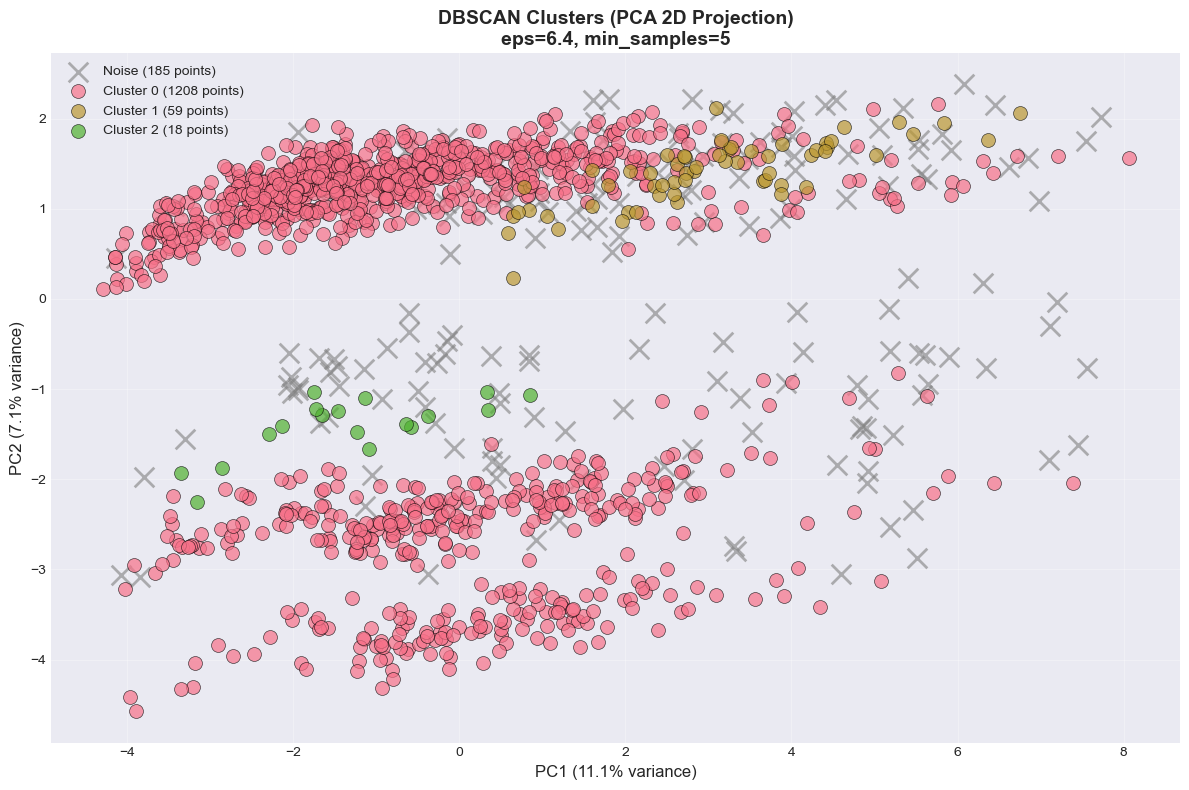


PCA (2D plot): PC1 = 11.1% of total variance, PC2 = 7.1%, combined = 18.2%
Note: DBSCAN used all 50 feature dimensions; the plot is only a 2D view.


In [29]:
# Visualize clusters using PCA (reduce to 2D)
# Clustering was run on all feature columns (same matrix as X_scaled before Cluster was added)
print("\nCreating PCA visualization...")

pca = PCA(n_components=2)  # 2D projection for plotting only
X_for_pca = X_scaled.drop('Cluster', axis=1)
X_pca = pca.fit_transform(X_for_pca)

plt.figure(figsize=(12, 8))

# Plot noise points as gray X's
noise_mask = clusters == -1
if noise_mask.sum() > 0:
    plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
               c='gray', marker='x', s=200, linewidth=2, alpha=0.6,
               label=f'Noise ({noise_mask.sum()} points)')

# Plot each cluster with different color
colors = plt.cm.Set3(np.linspace(0, 1, max(len(set(clusters)) - 1, 1)))
for i, cluster_id in enumerate(sorted(set(clusters) - {-1})):
    cluster_mask = clusters == cluster_id
    plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
               s=100, alpha=0.7, edgecolors='black', linewidth=0.5,
               label=f'Cluster {cluster_id} ({cluster_mask.sum()} points)')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'DBSCAN Clusters (PCA 2D Projection)\neps={best_eps}, min_samples={min_samples}',
         fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Share of total variance in the scaled feature space (PC1 + PC2)
var_two = float(pca.explained_variance_ratio_.sum())
var_pc1 = float(pca.explained_variance_ratio_[0])
var_pc2 = float(pca.explained_variance_ratio_[1])
print(f"\nPCA (2D plot): PC1 = {var_pc1:.1%} of total variance, PC2 = {var_pc2:.1%}, combined = {var_two:.1%}")
print(f"Note: DBSCAN used all {X_for_pca.shape[1]} feature dimensions; the plot is only a 2D view.")

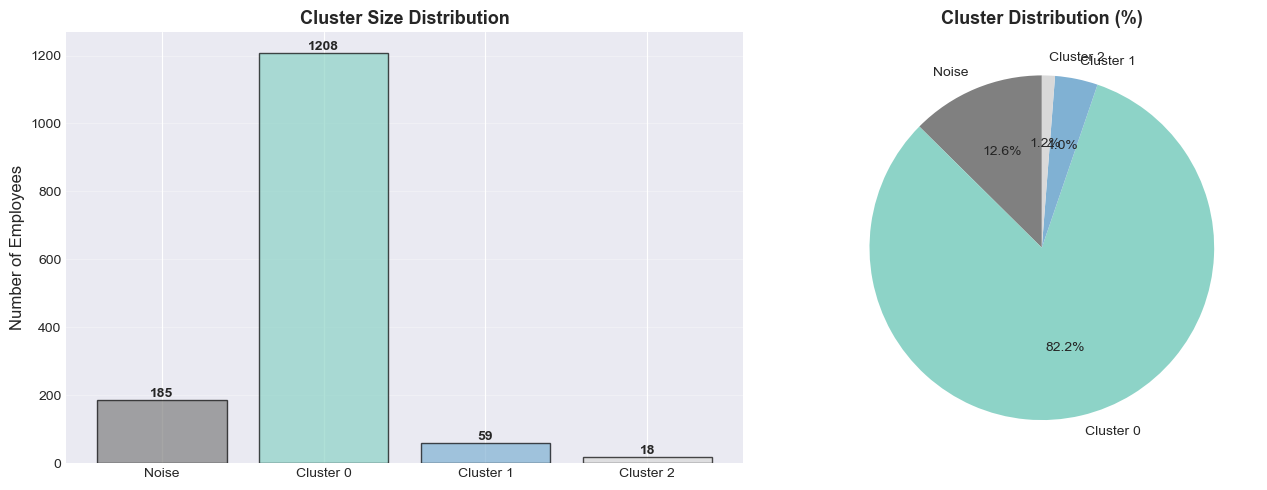

In [30]:
# Create bar chart and pie chart of cluster sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cluster_labels = []
cluster_sizes = []
colors_list = []

# Prepare data for both charts
for cluster_id in sorted(set(clusters)):
    size = (clusters == cluster_id).sum()
    if cluster_id == -1:
        cluster_labels.append('Noise')
        colors_list.append('gray')
    else:
        cluster_labels.append(f'Cluster {cluster_id}')
        colors_list.append(plt.cm.Set3(cluster_id / max(len(set(clusters)) - 1, 1)))
    cluster_sizes.append(size)

# Bar chart
bars = ax1.bar(cluster_labels, cluster_sizes, color=colors_list, edgecolor='black', alpha=0.7)
ax1.set_ylabel('Number of Employees', fontsize=12)
ax1.set_title('Cluster Size Distribution', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
ax2.pie(cluster_sizes, labels=cluster_labels, autopct='%1.1f%%', colors=colors_list, startangle=90)
ax2.set_title('Cluster Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Agglomerative Hierarchical Clustering

---

## **Cluster Interpretation & Profiles**


### 1. K-means

### 2. DBSCAN
For each cluster, we show its size, attrition rate, and average values for key features to understand what each cluster represents

**Note**: Clustering was performed on X_scaled as usual. However, z-scored values are not human-readable for interpretation, so the profiles below use the original raw dataset purely for display — to show real units like age in years and income in dollars.

In [31]:
# Load raw dataset for readable profile values (original units before any scaling)
df_raw = pd.read_csv('Dataset/Raw_Kaggle_HR_Employee_Attrition_data.csv')

# Align raw data with cluster labels using the same index
df_raw['Cluster'] = clusters

# Key features to profile — using readable columns from raw data
key_features = ['Age', 'YearsAtCompany', 'MonthlyIncome', 'JobSatisfaction']

print("="*70)
print("CLUSTER PROFILES")
print("="*70)

for cluster_id in sorted(set(clusters)):
    cluster_mask = clusters == cluster_id
    cluster_data_raw = df_raw[cluster_mask]
    
    size = cluster_mask.sum()
    pct = (size / len(clusters)) * 100
    
    print(f"\n{'='*70}")
    if cluster_id == -1:
        print(f"NOISE/OUTLIERS: {size} employees ({pct:.1f}%)")
    else:
        print(f"CLUSTER {cluster_id}: {size} employees ({pct:.1f}%)")
    print(f"{'='*70}")
    
    # Attrition rate from raw data (still has Yes/No strings)
    attrition_rate = (cluster_data_raw['Attrition'] == 'Yes').mean() * 100
    print(f"\nAttrition Rate: {attrition_rate:.1f}%")
    
    # Readable feature statistics in original units
    print(f"\nKey Feature Statistics (Mean ± Std):")
    for feature in key_features:
        if feature in cluster_data_raw.columns:
            mean = cluster_data_raw[feature].mean()
            std = cluster_data_raw[feature].std()
            print(f"  {feature:20s}: {mean:7.2f} ± {std:5.2f}")

CLUSTER PROFILES

NOISE/OUTLIERS: 185 employees (12.6%)

Attrition Rate: 16.2%

Key Feature Statistics (Mean ± Std):
  Age                 :   42.31 ±  9.65
  YearsAtCompany      :   11.48 ±  9.22
  MonthlyIncome       : 10327.59 ± 6028.97
  JobSatisfaction     :    2.61 ±  1.11

CLUSTER 0: 1208 employees (82.2%)

Attrition Rate: 16.7%

Key Feature Statistics (Mean ± Std):
  Age                 :   35.80 ±  8.68
  YearsAtCompany      :    6.20 ±  5.06
  MonthlyIncome       : 5478.02 ± 3594.95
  JobSatisfaction     :    2.75 ±  1.10

CLUSTER 1: 59 employees (4.0%)

Attrition Rate: 0.0%

Key Feature Statistics (Mean ± Std):
  Age                 :   43.98 ±  8.32
  YearsAtCompany      :   10.15 ±  7.44
  MonthlyIncome       : 16297.69 ± 2805.49
  JobSatisfaction     :    2.76 ±  1.07

CLUSTER 2: 18 employees (1.2%)

Attrition Rate: 27.8%

Key Feature Statistics (Mean ± Std):
  Age                 :   33.72 ±  5.44
  YearsAtCompany      :    4.78 ±  3.25
  MonthlyIncome       : 3872.06 ± 


DBSCAN identified 3 clusters plus noise/outliers across 1,470 employees. The clustering reflects the dataset's natural structure — the majority of employees share similar feature profiles, which is consistent with the 84%/16% class imbalance present in the original dataset.

#### Cluster 0: The Typical Workforce (1,208 employees, 82.2%)
- **Attrition:** 16.7% (matches company average)
- **Profile:** Average age 35.8, 6.2 years at company, $5,478 monthly income, moderate satisfaction
- **Risk:** AVERAGE — This is the core workforce. No single retention strategy fits all, but maintaining engagement and career growth opportunities is key

#### Cluster 1: Senior High-Earners (59 employees, 4.0%)
- **Attrition:** 0.0% (perfect retention)
- **Profile:** Older employees (avg 44), long tenure (10.2 years), highest income ($16,298), moderate satisfaction
- **Risk:** NONE — Well-compensated experienced employees who are not leaving. Protect their compensation and recognition

#### Cluster 2: Junior Low-Earners (18 employees, 1.2%)
- **Attrition:** 27.8% (nearly double the company average — CRITICAL)
- **Profile:** Youngest group (avg 34), shortest tenure (4.8 years), lowest income ($3,872), lowest satisfaction
- **Risk:** CRITICAL — Despite being a small group, their attrition rate is alarming. Low pay and short tenure suggest early-career dissatisfaction.


#### Noise/Outliers (185 employees, 12.6%)
- **Attrition:** 16.2% (matches company average)
- **Profile:** Older employees (avg 42), long tenure (11.5 years), high income ($10,327) — atypical profiles that do not fit any cluster
- **Risk:** MODERATE — Their mixed characteristics suggest individualized HR attention is needed rather than a group strategy.


#### Summary

**Findings:**
- Cluster 2 has 27.8% attrition — nearly double the average — CRITICAL
- Cluster 1 has 0% attrition — senior high-earners never leave, keep them happy
- Cluster 0 (82.2%) matches company average — stable but needs engagement
- 12.6% are outliers — no single strategy fits them

**Key Actions Needed:**
1. **URGENT:** Investigate Cluster 2 — young, lowest-paid employees are leaving at an alarming rate
2. **PROTECT:** Cluster 1 — senior high-earners have perfect retention, maintain their compensation
3. **MAINTAIN:** Cluster 0 — your core workforce, invest in career growth and satisfaction
4. **INDIVIDUALIZE:** Noise employees have atypical profiles, they need personalized HR attention


### 3. Agglomerative Hierarchical Clustering

---

## **Integration Strategy**

### 1. K-means

### 2. DBSCAN


#### How Clusters Improve our System

**Personalized Risk Assessment:**
- Cluster 0 → AVERAGE attrition risk (16.7%) — monitor and engage
- Cluster 1 → NO risk (0.0%) — maintain current conditions
- Cluster 2 → Predict HIGH attrition risk (27.8%) — FLAG FOR INTERVENTION
- Outliers → MODERATE risk (16.2%) — requires individual review

**Tailored Retention Strategies:**
- **Cluster 0:** Career development programs (they're engaged, invest in growth)
- **Cluster 1:** Maintain engagement and compensation (don't lose your experts)
- **Cluster 2:** Review junior compensation and provide early career support (lowest paid, highest attrition)
- **Outliers:** Individual HR conversations (each is unique)

**For Our Attrition Prediction Model:**
- We would add cluster membership as a feature to our supervised learning models
- Different clusters will have different attrition patterns
- Model can learn cluster-specific risk factors
- Makes predictions more explainable where HR can understand why an employee is flagged as high risk


### 3. Agglomerative Hierarchical Clustering

---

## **Challenges & Limitations**

### 1. K-means

### 2. DBSCAN

**Challenge 1: Parameter Sensitivity**
eps is highly sensitive — small changes produce very different clustering results. We mitigated this by running a broad sweep across 8 eps values, evaluating each using a combined Silhouette and Davies-Bouldin score, and filtering out any result where a single cluster absorbed more than 92% of the data. This systematic approach led to selecting eps=6.4 as the most balanced value.

**Challenge 2: Dataset Imbalance Driving Cluster Dominance**
The IBM HR dataset is strongly imbalanced — 84% of employees did not leave. Because clustering has no label to guide it, DBSCAN detected this imbalance as a density structure: the majority of employees share similar feature profiles and naturally form one dominant cluster (Cluster 0, 82.2%). This is not an algorithmic failure — it accurately reflects the data's geometry. However, it limits the granularity of insights DBSCAN can provide on this dataset.

**Challenge 3: Small Cluster Sample Sizes**
Clusters 1 and 2 contain only 59 and 18 employees respectively. While their attrition rates (0.0% and 27.8%) are striking, conclusions based on small groups should be treated as indicative rather than definitive. A larger dataset with more attrition cases would produce more statistically reliable cluster profiles.

**Challenge 4: Fair Quality Metrics**
Silhouette Score (0.1319) and Davies-Bouldin Index (1.6778) reflect fair rather than excellent separation. This is expected given the data imbalance and the high-dimensional feature space (50 features). Clusters should be used as guides to support HR decisions — combined with other signals like manager feedback and performance reviews — rather than treated as absolute truths.

**Challenge 5: Limited 2D Interpretability**
The PCA visualization only captures 18.2% of total variance (PC1=11.1%, PC2=7.1%). Clusters that appear overlapping in the 2D plot may be more separated in the full 50-dimensional space where DBSCAN actually operated. The plot is useful for a general overview but should not be used to judge cluster quality visually.

### 3. Agglomerative Hierarchical Clustering